In [1]:
#Bibliotecas
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#Leitura de Dados
df = sns.load_dataset("tips")

In [3]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
#Explorando os Tipos de Variáveis
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [5]:
#explorando os tipos de variáveis
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


#### As variáveis que aparecem como Float64 ou Int64, representa, escalas intervalares ou de razão, pois lidam com valores quantitativos

#### As variáveis categóricas aparecem como ovject ou category e representam escalas nominais ou ordinais, dependendo se há ordem entre as categorias.

In [6]:
#classificação de variáveis

def classificar_variavel(serie):
    if serie.dtype == "object" or serie.dtype.name == "category":
        #valores que não tem ordem natural -> nominal
        return "Nominal"
    
    #numericos
    if serie.dtype in ["int64", "float64"]:
        # variaveis nnumerias que não podem ser zero: intervalo
        # mas isso depende de contexto -> aqui vamos classificar pelo uso comum do dataset
        #valores que tem ordem natural -> ordinal
        if serie.name in ["total_bill", "tip", "size"]:
            return "Razão"
        else:
            return "Intervalar"
        
    return "Desconhecido"

#### Aplicando na nossa base de dados


In [7]:
tipos = {col: classificar_variavel(df[col]) for col in df.columns}
tipos

{'total_bill': 'Razão',
 'tip': 'Razão',
 'sex': 'Nominal',
 'smoker': 'Nominal',
 'day': 'Nominal',
 'time': 'Nominal',
 'size': 'Razão'}

In [8]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## VISUALIZANDO AS VARIÁVEIS QUALITATIVAS

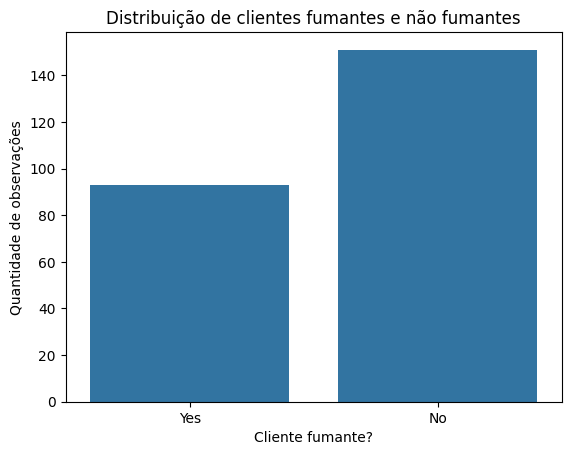

In [9]:

#VARIÁVEIS CATEGÓRICAS (NOMINAIS OU ORDINAIS)

sns.countplot(data=df, x='smoker')
plt.title('Distribuição de clientes fumantes e não fumantes')
plt.xlabel('Cliente fumante?')
plt.ylabel('Quantidade de observações')
plt.show()


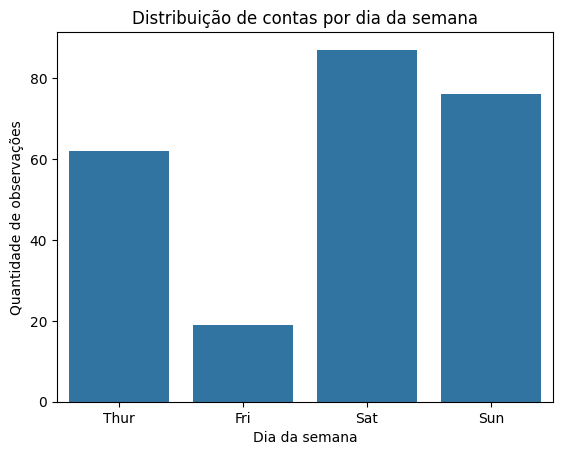

In [10]:
#DISTRIBUIÇÃO POR DIA DA SEMANA
sns.countplot(data=df, x='day', order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title('Distribuição de contas por dia da semana')
plt.xlabel('Dia da semana')
plt.ylabel('Quantidade de observações')
plt.show()


## VISUALIZANDO VARIAVEIS QUANTITATIVAS

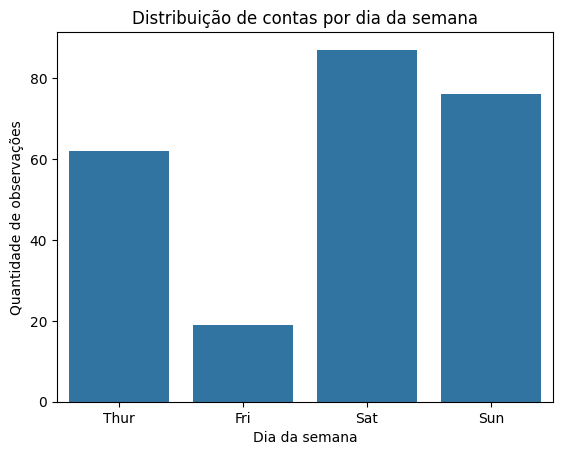

In [11]:
# VARIÁVEIS NUMÉRICAS, ESCALA DE RAZÃO OU INTERVALAR

# DISTRIBUIÇÃO TOTAL DA CONTA
sns.countplot(data=df, x='day', order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title('Distribuição de contas por dia da semana')
plt.xlabel('Dia da semana')
plt.ylabel('Quantidade de observações')
plt.show()


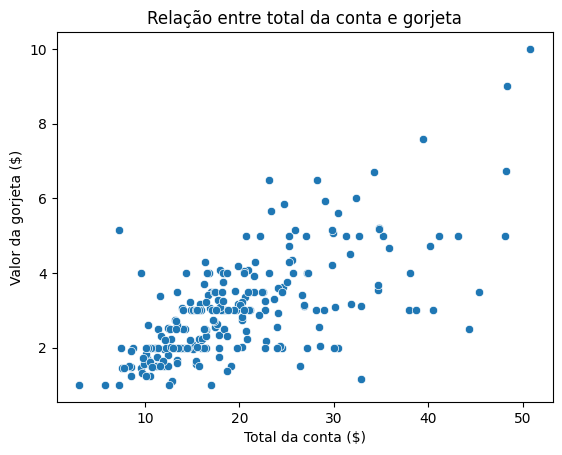

In [12]:
# RELAÇÃO ENTRE VALOR DA CONTA E GORJETA

sns.scatterplot(data=df, x='total_bill', y='tip')
plt.title('Relação entre total da conta e gorjeta')
plt.xlabel('Total da conta ($)')
plt.ylabel('Valor da gorjeta ($)')
plt.show()


## COMO IDENTIFICA A ESCALA DE MEDIÇÃO NA PRÁTICA

In [13]:
def identificar_escalas(df):
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64']:
            print(f"{col} → Quantitativa (provavelmente Escala de Razão)")
        else:
            print(f"{col} → Qualitativa (provavelmente Escala Nominal ou Ordinal)")
identificar_escalas(df)


total_bill → Quantitativa (provavelmente Escala de Razão)
tip → Quantitativa (provavelmente Escala de Razão)
sex → Qualitativa (provavelmente Escala Nominal ou Ordinal)
smoker → Qualitativa (provavelmente Escala Nominal ou Ordinal)
day → Qualitativa (provavelmente Escala Nominal ou Ordinal)
time → Qualitativa (provavelmente Escala Nominal ou Ordinal)
size → Quantitativa (provavelmente Escala de Razão)


In [14]:
df.head(10)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


In [15]:
#verificação do tipo de gráfico mais adequado para cada variável
def sugerir_grafico(tipo):
    if tipo == "Nominal":
        return "Gráfico de Barras ou Setores (Barplot)"
    elif tipo == "Ordinal":
        return "Gráfico de Barras ou Setores (Barplot Ordenado)"
    elif tipo == "Intervalar":
        return "Histograma ou Boxplot"
    elif tipo == "Razão":
        return "Histograma, Boxplot ou Gráfico de Dispersão (Proporção)"
    else:
        return "Tipo desconhecido"
    
    sugestoes = {col: sugerir_grafico(tp) for col, tp in tipos.items()}
    return sugestoes